In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

In [2]:
df = pd.read_csv("supply_chain_enriched.csv")

# Drop rows with missing target
df = df.dropna(subset=["service_level"])

In [3]:
# Select features for KNN
features = [
    "unit_quantity",
    "weight",
    "avg_freight_rate",
    "avg_transit_days",
    "wh_cost_per_unit",
    "wh_daily_capacity",
    "estimated_order_cost",
    "capacity_load_ratio",
    "valid_route",
    "is_vmi_customer",
    "is_nl_destination",
    "ship_ahead_day_count",
    "ship_late_day_count",
]

In [4]:
X = df[features].fillna(0)
y = df["service_level"]

# Encode target labels to numbers
le = LabelEncoder()
y = le.fit_transform(y)

In [5]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [6]:
# Normalize features — critical for KNN since it uses distance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [7]:
# Find the best K using grid search
param_grid = {"n_neighbors": [3, 5, 7, 9, 11, 15]}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="f1_weighted")
grid.fit(X_train, y_train)

print("Best K:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 4))

Best K: {'n_neighbors': 3}
Best CV F1: 0.9948


In [8]:
# Evaluate on test set
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))



Classification Report:
              precision    recall  f1-score   support

         DTD       0.99      0.99      0.99       429
         DTP       1.00      1.00      1.00      1244

    accuracy                           0.99      1673
   macro avg       0.99      0.99      0.99      1673
weighted avg       0.99      0.99      0.99      1673



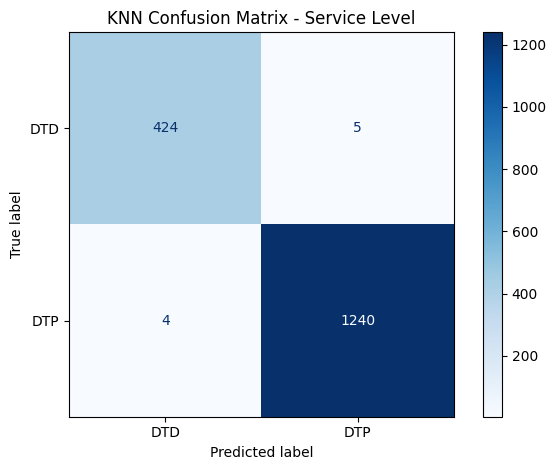

Saved confusion_matrix.png


In [9]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("KNN Confusion Matrix - Service Level")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved confusion_matrix.png")


In [10]:
# Plot K vs F1 score
k_values = param_grid["n_neighbors"]
f1_scores = grid.cv_results_["mean_test_score"]

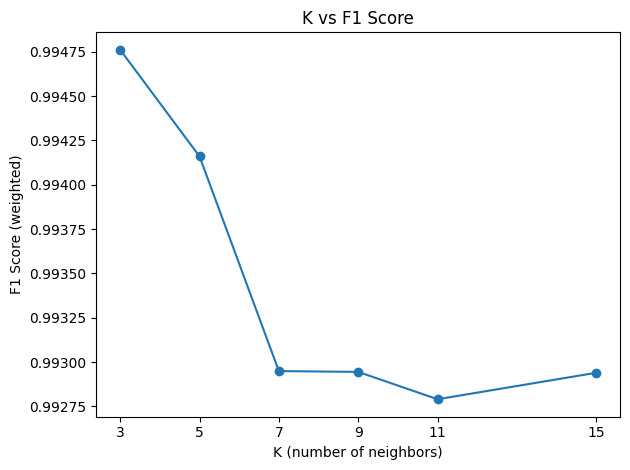

In [11]:
plt.figure()
plt.plot(k_values, f1_scores, marker="o")
plt.title("K vs F1 Score")
plt.xlabel("K (number of neighbors)")
plt.ylabel("F1 Score (weighted)")
plt.xticks(k_values)
plt.tight_layout()
plt.savefig("k_vs_f1.png", dpi=150)
plt.show()

### Boundary Plot

In [21]:
X_scaled = scaler.fit_transform(X)

In [25]:
# Reduce 13 features down to 2 dimensions for plotting
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")


Variance explained by 2 components: 46.29%


In [26]:
# Train KNN on the 2D version
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_2d, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [29]:
# Build a mesh grid to color the decision regions
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


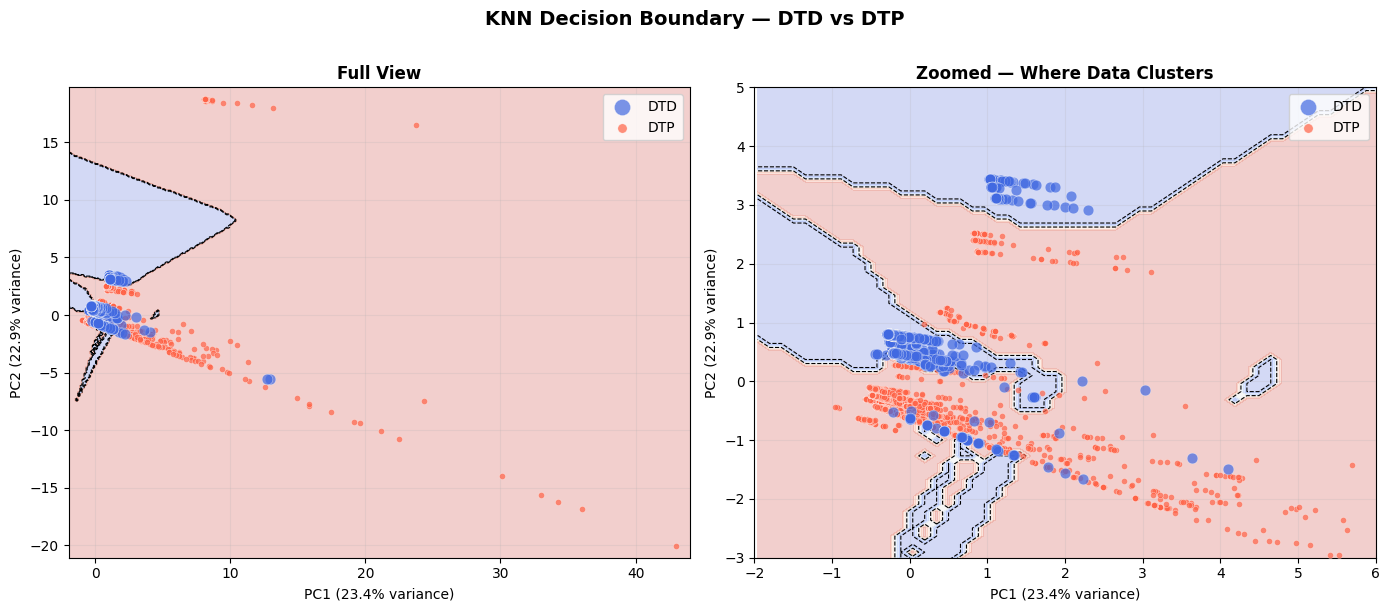

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, zoom, title in zip(axes, [False, True], ["Full View", "Zoomed — Where Data Clusters"]):
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.contour(xx, yy, Z, levels=1, colors="black", linewidths=0.8, linestyles="--")

    for cls, color, label, size, zorder in zip(
        [0, 1], ["royalblue", "tomato"], ["DTD", "DTP"], [60, 20], [5, 3]
    ):
        mask = y == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, label=label, alpha=0.7, s=size,
                   edgecolors="white", linewidths=0.3, zorder=zorder)

    if zoom:
        ax.set_xlim(-2, 6)
        ax.set_ylim(-3, 5)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
    ax.legend(markerscale=1.5)
    ax.grid(True, alpha=0.2)

plt.suptitle("KNN Decision Boundary — DTD vs DTP", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("knn_decision_boundary.png", dpi=150, bbox_inches="tight")
plt.show()

### Sanity Check

In [12]:
print(df.groupby("service_level")[["avg_freight_rate", "avg_transit_days", 
                                    "unit_quantity", "weight"]].mean())

               avg_freight_rate  avg_transit_days  unit_quantity     weight
service_level                                                              
DTD                    0.237922          1.521465    1294.377508  12.946981
DTP                    0.121588          2.486330    3687.452235  19.342162


### KNN Regression

In [13]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [14]:
# Use all features except the target itself
reg_features = [f for f in features if f != "estimated_order_cost"]
y_reg = df["estimated_order_cost"].fillna(df["estimated_order_cost"].median())
X_reg = df[reg_features].fillna(0)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


In [15]:
# Normalize — same reason as classifier, KNN is distance based
scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r  = scaler_r.transform(X_test_r)

In [17]:
# Find best K for regression using R2 as scoring metric
grid_r = GridSearchCV(KNeighborsRegressor(), {"n_neighbors": [3, 5, 7, 9, 11, 15]}, cv=5, scoring="r2")
grid_r.fit(X_train_r, y_train_r)
best_knn_r = grid_r.best_estimator_
y_pred_r   = best_knn_r.predict(X_test_r)

print(f"Best K:  {grid_r.best_params_['n_neighbors']}")
print(f"R2:      {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAE:  {mean_absolute_error(y_test_r, y_pred_r):.2f}")

Best K:  3
R2:      0.9758
MAE:  123.11


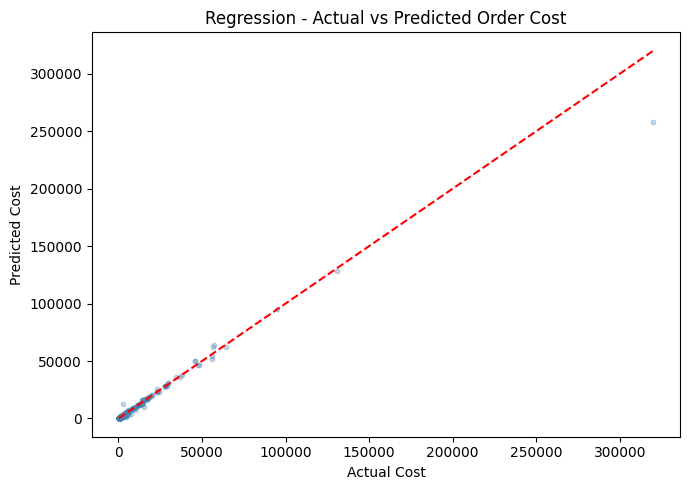

In [18]:
# Actual vs predicted scatter plot — red line = perfect prediction
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, color="steelblue", s=10)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], "r--")
plt.title("Regression - Actual vs Predicted Order Cost")
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()

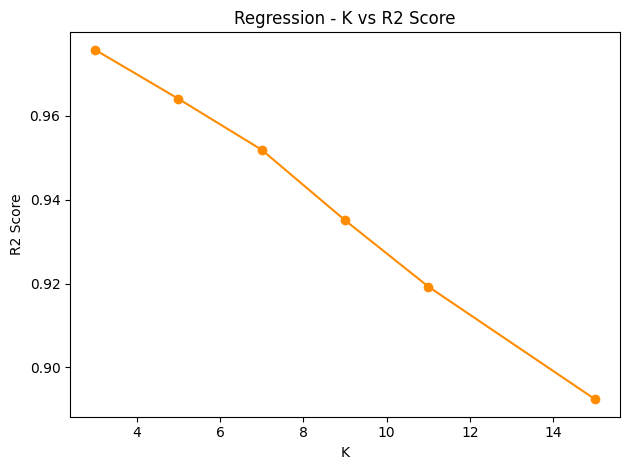

In [19]:
# K vs R2 to visualize how K affects regression performance
plt.figure()
plt.plot([3, 5, 7, 9, 11, 15], grid_r.cv_results_["mean_test_score"], marker="o", color="darkorange")
plt.title("Regression - K vs R2 Score")
plt.xlabel("K")
plt.ylabel("R2 Score")
plt.tight_layout()
plt.savefig("k_vs_r2_regression.png", dpi=150)
plt.show()

### Logistical Regression

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [34]:
print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

         DTD       1.00      0.98      0.99       429
         DTP       0.99      1.00      1.00      1244

    accuracy                           0.99      1673
   macro avg       1.00      0.99      0.99      1673
weighted avg       0.99      0.99      0.99      1673



In [35]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig("lr_confusion_matrix.png", dpi=150)
plt.close()

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="steelblue", label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "r--", label="Random guess")
plt.title("Logistic Regression — ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("lr_roc_curve.png", dpi=150)
plt.close()

In [38]:
# Coefficients — shows which features push toward DTP vs DTD
coef_df = pd.DataFrame({"feature": features, "coefficient": model.coef_[0]})
coef_df = coef_df.sort_values("coefficient")

plt.figure(figsize=(8, 6))
colors = ["tomato" if c > 0 else "steelblue" for c in coef_df["coefficient"]]
plt.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression — Feature Coefficients\n(red = pushes toward DTP, blue = pushes toward DTD)")
plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=150)
plt.close()